In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
df = yf.download(['BZ=F', 'INDIGO.NS', 'ASIANPAINT.NS', 'HINDUNILVR.NS'], start='2010-01-01')['Close']
df

[*********************100%***********************]  4 of 4 completed


Ticker,ASIANPAINT.NS,BZ=F,HINDUNILVR.NS,INDIGO.NS
Date,,,,
2010-01-04,155.179764,80.120003,197.109497,NaN
2010-01-05,155.669846,80.589996,196.476517,NaN
2010-01-06,155.201340,81.889999,197.593491,NaN
2010-01-07,153.618103,81.510002,197.183929,NaN
2010-01-08,156.155716,81.370003,198.040359,NaN
...,...,...,...,...
2026-04-13,2352.399902,99.360001,2127.199951,4427.200195
2026-04-14,NaN,94.790001,NaN,NaN
2026-04-15,2423.100098,94.930000,2157.600098,4638.000000


In [3]:
df.dropna()
df.columns = ['AsianPaints', 'Brent', 'HUL', 'IndiGo']

In [4]:
log_returns = np.log(df/df.shift(1)).dropna()
log_returns * 100

,AsianPaints,Brent,HUL,IndiGo
Date,,,,
2015-11-16,0.068693,-0.068812,-1.594156,-1.520313
2015-11-17,0.833045,-0.022954,1.794794,4.734694
2015-11-18,1.730738,1.299755,-0.603089,0.840336
2015-11-19,0.237022,0.090582,0.138529,8.971731
2015-11-20,0.665504,1.080604,0.445783,-3.414880
...,...,...,...,...
2026-04-09,-0.562383,1.227265,-0.579610,-3.671835
2026-04-10,3.935452,-0.753458,1.030677,2.334808
2026-04-13,-0.352212,4.276971,-1.312341,-2.828255


In [5]:
window = 126

rolling_corr = log_returns.rolling(window).corr()

In [6]:
corr_crude = (rolling_corr.xs('Brent', level=1).drop(columns='Brent'))

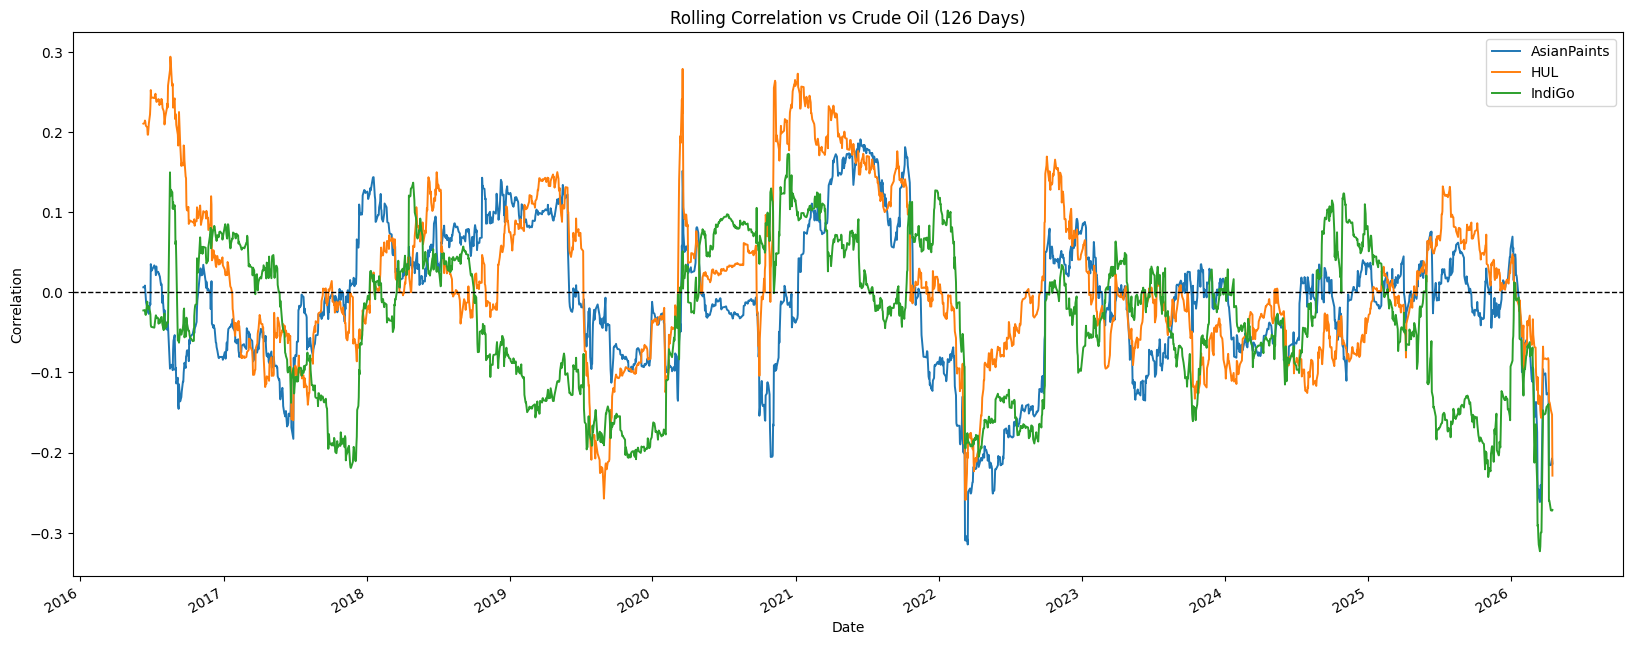

In [7]:
corr_crude.plot(figsize=(20,8),linewidth=1.4)
plt.axhline(0, ls='--', c='black', lw=1)

plt.title("Rolling Correlation vs Crude Oil (126 Days)")
plt.ylabel("Correlation")

plt.show()

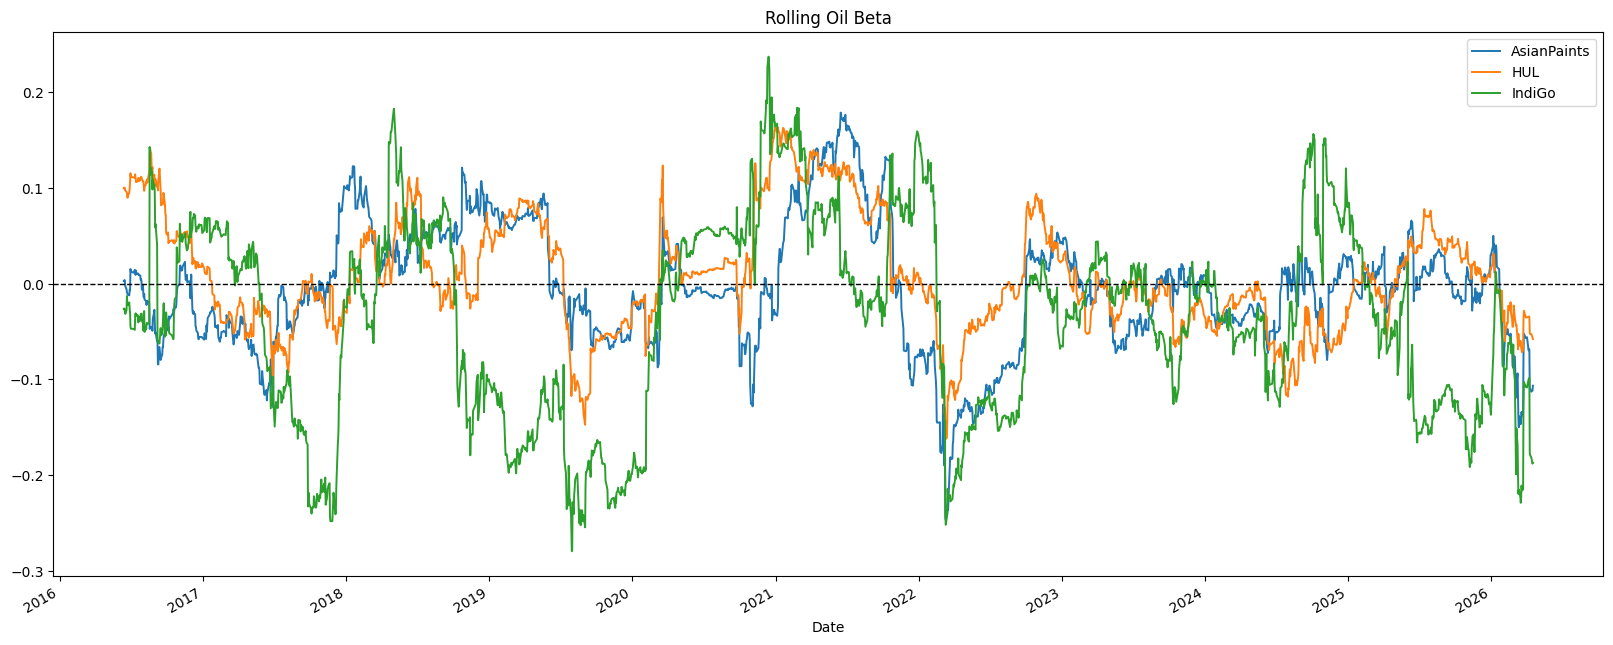

In [16]:
def rolling_beta(stock, oil, window=126):
    betas = []
    idx = stock.index[window:]
    
    for i in range(window, len(stock)):
        y = stock.iloc[i-window:i]
        x = sm.add_constant(oil.iloc[i-window:i])

        model = sm.OLS(y, x).fit()
        betas.append(model.params['Brent'])
    return pd.Series(betas, index=idx)

beta = pd.DataFrame({
    'AsianPaints': rolling_beta(log_returns['AsianPaints'], log_returns['Brent']),
    'HUL': rolling_beta(log_returns['HUL'], log_returns['Brent']),
    'IndiGo': rolling_beta(log_returns['IndiGo'], log_returns['Brent']),
})

beta.plot(figsize=(20,8),linewidth=1.4)
plt.title('Rolling Oil Beta')
plt.axhline(0, ls='--', c='black', lw=1)
plt.show()

In [18]:
shocks = {
    'COVID_2020':('2020-01-01','2020-04-30'),
    'Ukraine_war':('2022-01-01','2022-06-01')
}

shock_performance = {
    k:log_returns.loc[v[0]:v[1]].cumsum().iloc[-1]
    for k,v in shocks.items()
}

shock_performance = pd.DataFrame(shock_performance)

In [20]:
oil_down = log_returns[log_returns['Brent'] < 0]
oil_down[['IndiGo','AsianPaints','HUL']].mean()

IndiGo         0.000855
AsianPaints    0.000684
HUL            0.000572
dtype: float64